# Probe health with day-level embeddings
Following tutorial here: https://oxwearables.github.io/Sensori/tutorials/day-level-health/#prepare-the-analysis-data
The pre-processing notebook: tutorials/nhanes_preprocessing.ipynb(this outputs the .npy files same as my script is curently generating)
There is also the full tutorial notebook: tutorials/nhanes_evaluation.ipynb - I will be re-working this to operate on a small subset of my data


In [1]:
import json
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from umap import UMAP
import os

from scripts.tutorial_nhanes.prepare_nhanes_tabular import prepare_tabular
from sensori.inference import extract_embeddings # looks dodgy but does work

- first extract the embeddings - this code fetches the weights from huggingface

In [2]:
# Change this to the directory containing your preprocessed NHANES arrays.
PROCESSED_DATA_DIR = Path('/home/lucy/PycharmProjects/Sensori/data/processed')
EMBEDDING_PATH = Path('test_embeddings.npy')

# BATCH_SIZE = 100 needs about 70 GB of GPU memory for full-day inputs; reduce it if you run out.
BATCH_SIZE = 10
NUM_WORKERS = 6
SEED = 111

extract_embeddings(
    PROCESSED_DATA_DIR,
    output_path=EMBEDDING_PATH,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Total days loaded: 21
Total unique participants: 4
Loading data from: /home/lucy/PycharmProjects/Sensori/data/processed
Saving embeddings to: /home/lucy/PycharmProjects/Sensori/experiments/test_embeddings.npy


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/lucy/miniconda3/envs/Sensori/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Validation: |          | 0/? [00:00<?, ?it/s]

Saved embeddings to: /home/lucy/PycharmProjects/Sensori/experiments/test_embeddings.npy


PosixPath('/home/lucy/PycharmProjects/Sensori/experiments/test_embeddings.npy')

## Prepare tabular data
So I think here I will need to prep my target data in a specific format to fit with the downstream tasks... the code in the tutorial is looking at downloading specific formats from the NHANES database and converting it so I don't think that's super useful for my purposes.

In [3]:
df = pd.read_csv(os.path.join("..", "data", "timestamped_nep.csv"))

df = df[["Local.Participant", "visit.number", "timestamp_plus_one_NEP"]]

df = df.dropna(subset=["timestamp_plus_one_NEP"]).reset_index(drop=True)

df["visit.number"] = (df["visit.number"]).str.upper()

df["eid"] = (df["Local.Participant"].astype(str) + "_" + df["visit.number"])

tabular = df[["eid", "timestamp_plus_one_NEP"]]

tabular

,eid,timestamp_plus_one_NEP
0,10376_T1,0.0
1,10376_T2,0.0
2,10376_T3,0.0
3,10376_T4,0.0
4,10377_T1,0.0
...,...,...
2269,25238_T2,0.0
2270,25238_T3,0.0
2271,25238_T4,0.0
2272,25239_T1,0.0


## build participant-level embeddings
- just gonna extract a few more locally to make this match the example better
- so what's going on here... L2 normalisation and then averaging of day embeddings???
- then join to tabular (outcome) data

In [4]:
def load_participant_embeddings(path):
    day_embeddings = np.load(path, allow_pickle=True).item()
    participants = {}
    for eid, days in day_embeddings.items():
        days = np.asarray(days, dtype=np.float32)
        norms = np.linalg.norm(days, axis=1)
        valid = np.isfinite(norms) & (norms > 0)  # a non-finite day gives a non-finite norm
        if valid.any():
            participants[str(eid)] = (days[valid] / norms[valid, None]).mean(axis=0)

    frame = pd.DataFrame.from_dict(participants, orient='index')
    frame.index.name = 'eid'
    frame.columns = [f'embedding_{column:03d}' for column in range(frame.shape[1])]
    return frame


embeddings = load_participant_embeddings(EMBEDDING_PATH)
embedding_columns = embeddings.columns.tolist()
tabular['eid'] = tabular['eid'].astype(str)
cohort = tabular.set_index('eid').join(embeddings, how='inner')
print(f'Participants with tabular data and embeddings: {len(cohort):,}')
cohort.reset_index()[['eid', 'timestamp_plus_one_NEP']].head()

Participants with tabular data and embeddings: 4


/tmp/ipykernel_15283/3132676211.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabular['eid'] = tabular['eid'].astype(str)


,eid,timestamp_plus_one_NEP
0,10376_T1,0.0
1,10385_T2,1.0
2,24000_T1,0.0
3,25000_T1,0.0


## Umap visualisation
- so I think this is just based on correlation/regression between sensori embeddings and outcome vars? there is a bunch of stuff in here which really isn't clear about the firmware etc which ig is specific to the NHANES data?
- I don't realy understand it but will try to convert it as best I can
- I guess it will say more when we actually have more than 4 datapoint....

/home/lucy/miniconda3/envs/Sensori/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


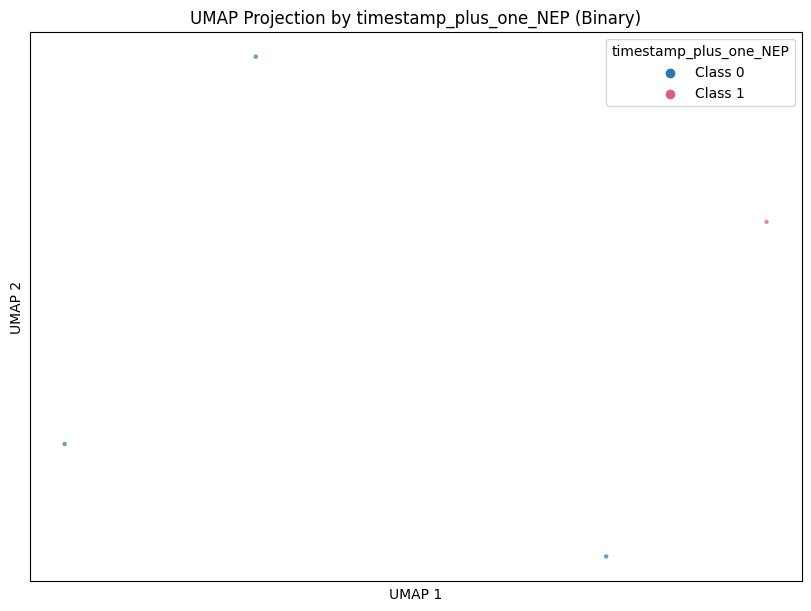

In [10]:
# gemini gave me this re-working of the umap chunk
# 1. Compute UMAP embeddings
umap_table = cohort.copy()
umap_table[['UMAP1', 'UMAP2']] = UMAP(
    n_neighbors=50, random_state=SEED, n_jobs=1
).fit_transform(umap_table[embedding_columns])

# 2. Filter out missing values and sample/shuffle points to avoid overplotting bias
plot_table = (
    umap_table.dropna(subset=['timestamp_plus_one_NEP'])
    .sample(frac=1, random_state=SEED)
)

# 3. Define explicit colors for class 0 and class 1
colors = {0: '#2878B5', 1: '#D95F82'}  # Blue for 0, Pink/Red for 1

# 4. Create the scatter plot
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Scatter plot using mapped colors
ax.scatter(
    plot_table['UMAP1'],
    plot_table['UMAP2'],
    c=plot_table['timestamp_plus_one_NEP'].map(colors),
    s=5,
    alpha=0.6,  # Helps visualize overlapping points
)

# Add legend entries manually
for label, color in colors.items():
    ax.scatter([], [], color=color, label=f'Class {label}')

# 5. Styling
ax.set_title('UMAP Projection by timestamp_plus_one_NEP (Binary)')
ax.set(xticks=[], yticks=[], xlabel='UMAP 1', ylabel='UMAP 2')
ax.legend(title='timestamp_plus_one_NEP')

plt.show()

## encode the evaluation targets
- tbh i am slightly losing the will to live - will pick this up tomorrow.
- maybe quickly before i go i can run a quick LR or something...

In [11]:
cohort

,timestamp_plus_one_NEP,embedding_000,embedding_001,embedding_002,embedding_003,embedding_004,embedding_005,embedding_006,embedding_007,embedding_008,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
eid,,,,,,,,,,,,,,,,,,,,,
10376_T1,0.0,0.052603,0.033473,-0.022729,-0.000160,0.047346,-0.002343,0.012521,-0.000240,0.030719,...,-0.016253,-0.015757,-0.022928,-0.024058,0.023281,0.013349,0.036425,0.015217,-0.010041,-0.016789
10385_T2,1.0,0.010299,0.022077,-0.060418,-0.014815,-0.000481,0.021880,0.013007,0.019935,0.000113,...,-0.012502,-0.035373,-0.034132,-0.012794,0.041760,0.020388,0.006763,0.004294,0.019017,0.012453
24000_T1,0.0,-0.016091,0.044377,-0.073921,0.002505,0.046650,0.005895,0.034536,-0.020407,0.019445,...,-0.030143,-0.031102,-0.005361,-0.041550,0.021138,0.029426,0.007579,0.015924,0.017933,-0.015557
25000_T1,0.0,0.038476,0.039760,-0.068429,0.016868,0.024424,0.014031,0.007558,-0.024148,0.015578,...,-0.019875,-0.031458,-0.026377,-0.027627,0.027670,0.024828,0.035533,-0.008818,0.026960,0.008649


In [12]:
# again gem just handed me this - will have to run it tomo when i have a bit more data!
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 1. Identify feature columns automatically (embedding_000 through embedding_XXX)
feature_cols = cohort.filter(regex=r'^embedding_').columns

# 2. Extract features and target, dropping rows with missing values
clean_df = cohort.dropna(subset=['timestamp_plus_one_NEP'] + list(feature_cols))
X = clean_df[feature_cols]
y = clean_df['timestamp_plus_one_NEP']

# 3. Split into train and test sets (stratified for binary balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# 4. Scale features (essential for high-dimensional embeddings)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression
# max_iter is increased to ensure convergence across ~700 features
clf = LogisticRegression(max_iter=1000, random_state=SEED)
clf.fit(X_train_scaled, y_train)

# 6. Evaluate
y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [1.0]